In [2]:
import os
import sys
from dask.distributed import Client
# client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler.json', threads_per_worker=2, n_workers=6)
client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler.json')  
# client = Client(scheduler_file='/proj/kimyy/Dropbox/source/python/all/mpi/scheduler_10.json')  

# add private module path for workers
# client.run(lambda: os.environ.update({'PYTHONPATH': '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2'}))
# def add_path():
#     if '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2' not in sys.path:
#         sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')

# client.run(add_path)

def setup_module_path():
    module_path = '/proj/kimyy/Dropbox/source/python/all/Modules/CESM2'
    if module_path not in sys.path:
        sys.path.append(module_path)

client.run(setup_module_path)

client

<Client: 'tcp://203.247.189.224:36466' processes=4 threads=72, memory=335.28 GiB>

# Load modules

In [3]:
# load public modules

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import cmocean
from cmcrameri import cm
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import cftime
import pop_tools
from pprint import pprint
import time
import subprocess
import re as re_mod
import cftime
import datetime
from scipy.stats import ttest_1samp
import xcesm

In [4]:
# load private modules

import sys
sys.path.append('/proj/kimyy/Dropbox/source/python/all/Modules/CESM2')
from KYY_CESM2_preprocessing import CESM2_config
# import KYY_CESM2_preprocessing
# import importlib
# importlib.reload(KYY_CESM2_preprocessing)

In [5]:
base_dir = (
    "/mnt/lustre/proj/kimyy/Model/CESM2/ESP/for_LIM/LIM_BGC_Justin_n_5/"
)

files = [
    f"{base_dir}/NPP_LIM_n_5_No_{i}.nc"
    for i in range(1, 51)
]

# sanity check
for f in files:
    if not os.path.exists(f):
        raise FileNotFoundError(f)

In [6]:
ds = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="ens_LE",
    engine="netcdf4",      # 안정성
    decode_cf=True,
    parallel=False         # HPC면 True 가능
)

# ens_LE 좌표 명시
ds = ds.assign_coords(ens_LE=np.arange(1, 51))

In [7]:
print(ds)

<xarray.Dataset> Size: 5MB
Dimensions:         (ens_LE: 50, month: 12, state_j: 5, state_i: 5, lead: 25,
                     state: 5, time: 792)
Coordinates:
  * ens_LE          (ens_LE) int64 400B 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50
Dimensions without coordinates: month, state_j, state_i, lead, state, time
Data variables: (12/19)
    A_CS_CW         (ens_LE, month, state_j, state_i) float64 120kB dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_ST_CW         (ens_LE, state_j, state_i) float64 10kB dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_CS_White      (ens_LE, month, state_j, state_i) float64 120kB dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_ST_White      (ens_LE, state_j, state_i) float64 10kB dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_CS_Colored    (ens_LE, month, state_j, state_i) float64 120kB dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_ST_Colored    (ens_LE, state_j, state_i) float64 10kB dask.array<chunksiz

('state_j', 'state_i')


Text(0, 0.5, 'Predictor (state_i)')

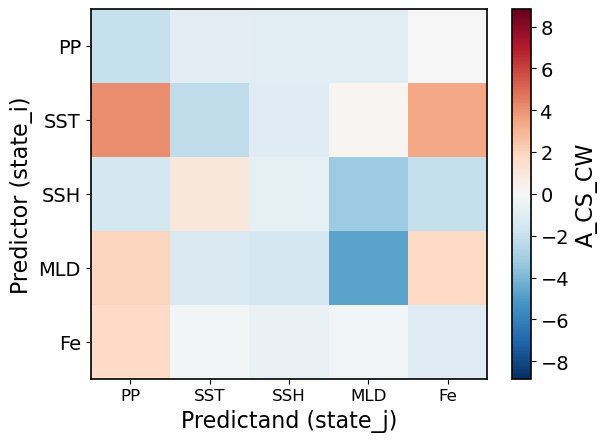

In [9]:
state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# da = ds['A_CS_CW'].isel(ens_LE=0).mean(dim='month')
da = ds['A_CS_CW'].mean(dim='ens_LE').mean(dim='month')

print(da.dims)
fig, ax = plt.subplots()

vmax = np.abs(
    ds["A_CS_CW"].isel(ens_LE=0).mean(dim="month")
).max().values

da.plot(
    ax=ax,              
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=+vmax,
    yincrease=False
)

ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(5))
ax.set_xticklabels(state_names)
ax.set_yticklabels(state_names)

ax.set_xlabel("Predictand (state_j)")
ax.set_ylabel("Predictor (state_i)")


('state_j', 'state_i')


Text(0, 0.5, 'Predictor (state_i)')

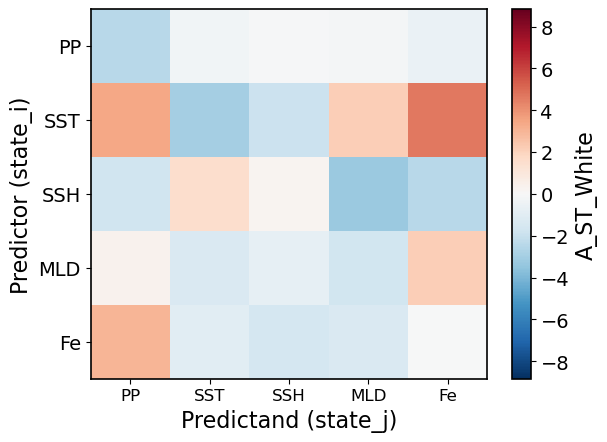

In [10]:
state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# da = ds['A_CS_CW'].isel(ens_LE=0).mean(dim='month')
da = ds['A_ST_White'].mean(dim='ens_LE')

print(da.dims)
fig, ax = plt.subplots()

vmax = np.abs(
    ds["A_CS_CW"].isel(ens_LE=0).mean(dim="month")
).max().values

da.plot(
    ax=ax,              
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=+vmax,
    yincrease=False
)

ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(5))
ax.set_xticklabels(state_names)
ax.set_yticklabels(state_names)

ax.set_xlabel("Predictand (state_j)")
ax.set_ylabel("Predictor (state_i)")


In [11]:
# A0 = ds['A_CS_CW'].isel(ens_LE=0, month=0)
A0 = ds['A_CS_CW'].mean(dim='ens_LE').mean(dim='month')

print("diag assuming (state_j,state_i):",
      np.diag(A0.values))
print("diag assuming swapped:",
      np.diag(A0.values.T))

diag assuming (state_j,state_i): [-2.01363847 -2.25078625 -0.80797236 -4.6957567  -1.06449433]
diag assuming swapped: [-2.01363847 -2.25078625 -0.80797236 -4.6957567  -1.06449433]


In [12]:
da = ds["A_CS_CW"]
print(da.dims)
print(da.shape)

('ens_LE', 'month', 'state_j', 'state_i')
(50, 12, 5, 5)


In [13]:
A0.isel(state_i=0).isel(state_j=1).values

array(4.076312)

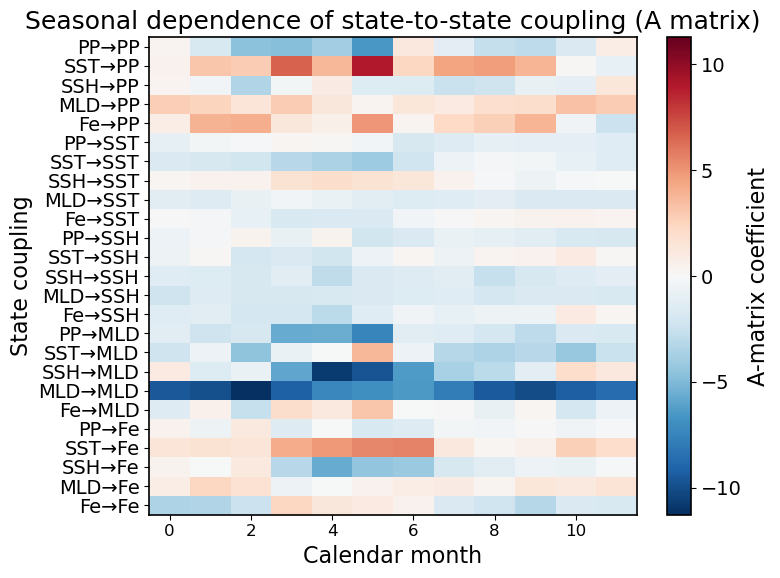

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# --------------------------------------------------
# 1. Load & select
# --------------------------------------------------
               
A = ds["A_CS_CW"].isel(ens_LE=0)
# A = A.transpose("month", "state_j", "state_i")
# dims expected: (month, state_i, state_j)

# --------------------------------------------------
# 2. (state_i, state_j) → single row dimension
# --------------------------------------------------
A_flat = A.stack(coupling=("state_i", "state_j"))
# dims: (month, coupling)

# coupling label 만들기
coupling_labels = [
    f"{state_names[j]}→{state_names[i]}"
    for i in range(5)
    for j in range(5)
]

A_flat = A_flat.assign_coords(
    coupling=("coupling", coupling_labels)
)

# --------------------------------------------------
# 3. Transpose to (coupling, month)
# --------------------------------------------------
A_plot = A_flat.transpose("coupling", "month")

# --------------------------------------------------
# 4. Color scale (diverging, symmetric)
# --------------------------------------------------
vmax = np.nanmax(np.abs(A_plot))

# --------------------------------------------------
# 5. Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

A_plot.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=+vmax,
    yincrease=False,
    cbar_kwargs={"label": "A-matrix coefficient"}
)

n_row = A_plot.sizes["coupling"]
ax.set_ylim(n_row - 0.5, -0.5)
n_col = A_plot.sizes["month"]
ax.set_xlim(-0.5, n_col - 0.5)


ax.set_xlabel("Calendar month")
ax.set_ylabel("State coupling")

plt.title("Seasonal dependence of state-to-state coupling (A matrix)")
plt.tight_layout()
plt.show()


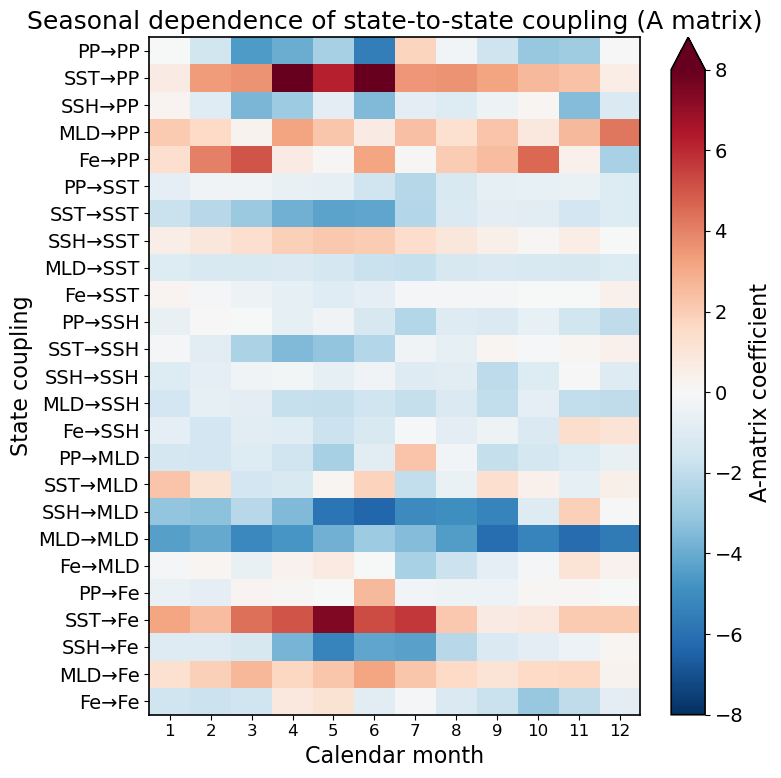

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# --------------------------------------------------
# 1. Load & select
# --------------------------------------------------
A = ds["A_CS_CW"].mean(dim='ens_LE')
# A = A.transpose("month", "state_j", "state_i")
# dims expected: (month, state_i, state_j)

# --------------------------------------------------
# 2. (state_i, state_j) → single row dimension
# --------------------------------------------------
# state_j: predictor dimension
A_flat = A.stack(coupling=("state_i", "state_j"))
# dims: (month, coupling)

# coupling label 만들기
coupling_labels = [
    f"{state_names[j]}→{state_names[i]}"
    # f"{state_names[i]}→{state_names[j]}"

    for i in range(5)
    for j in range(5)
]

A_flat = A_flat.assign_coords(
    coupling=("coupling", coupling_labels)
)

# --------------------------------------------------
# 3. Transpose to (coupling, month)
# --------------------------------------------------
A_plot = A_flat.transpose("coupling", "month")

# --------------------------------------------------
# 4. Color scale (diverging, symmetric)
# --------------------------------------------------
vmax = np.nanmax(np.abs(A_plot))

# --------------------------------------------------
# 5. Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# A_plot.plot(
#     ax=ax,
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=+vmax,
#     yincrease=False,
#     cbar_kwargs={"label": "A-matrix coefficient"}
# )

A_plot.plot(
    ax=ax,
    cmap="RdBu_r",
    vmin=-8,
    vmax=+8,
    yincrease=False,
    cbar_kwargs={"label": "A-matrix coefficient"}
)

n_row = A_plot.sizes["coupling"]
ax.set_ylim(n_row - 0.5, -0.5)
n_col = A_plot.sizes["month"]
ax.set_xlim(-0.5, n_col - 0.5)

ax.set_xticks(np.arange(n_col) + 0.0)
ax.set_xticklabels(np.arange(1, n_col + 1))

ax.set_xlabel("Calendar month")
ax.set_ylabel("State coupling")

plt.title("Seasonal dependence of state-to-state coupling (A matrix)")
plt.tight_layout()
plt.show()


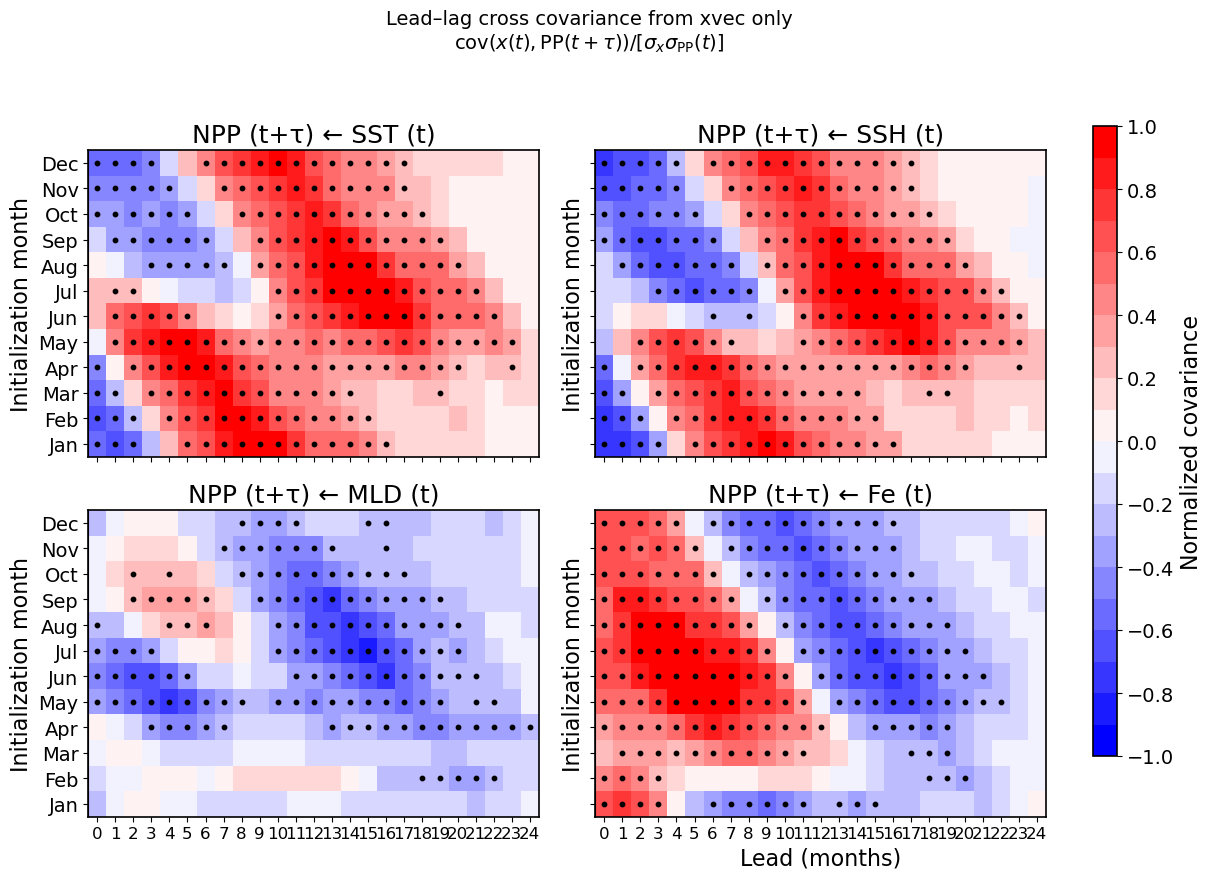

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from matplotlib.colors import ListedColormap

# ==========================================================
# 0. Settings
# ==========================================================
ens = 0
max_lag = 24
n_month = 12

predictors = {
    1: "SST",
    2: "SSH",
    3: "MLD",
    4: "Fe",
}

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# ===== DOF (same as MATLAB) =====
N = 64
nu = N - 2
tcrit = t.ppf(1 - 0.05/2, nu)
rcrit = np.sqrt(tcrit**2 / (tcrit**2 + nu))

# ==========================================================
# 1. Prepare data
# ==========================================================
xvec = ds["xvec"].isel(ens_LE=ens).values   # (time, state)
nt, n_state = xvec.shape

# month index for each time index (assumes continuous monthly data)
month_idx = np.tile(np.arange(n_month), nt // n_month)

# ==========================================================
# 2. Month-wise PP(t) std for normalization
# ==========================================================
pp0_std = np.full(n_month, np.nan)

for m in range(n_month):
    mask = month_idx == m
    pp0 = xvec[mask, 0]
    if np.isfinite(pp0).sum() >= 10:
        pp0_std[m] = np.nanstd(pp0, ddof=1)

# ==========================================================
# 3. Compute lead–lag covariance normalized by PP(t)
# ==========================================================
corr_maps = {}

for pidx, pname in predictors.items():

    C = np.full((n_month, max_lag + 1), np.nan)

    for m in range(n_month):

        for lag in range(max_lag + 1):

            if lag == 0:
                tmask = month_idx == m
                x = xvec[tmask, pidx]
                y = xvec[tmask, 0]

            else:
                t0 = np.where(month_idx[:-lag] == m)[0]
                t1 = t0 + lag
                x = xvec[t0, pidx]   # predictor at t
                y = xvec[t1, 0]      # PP at t+tau

            valid = np.isfinite(x) & np.isfinite(y)
            if valid.sum() < 10:
                continue

            xv = x[valid]
            yv = y[valid]

            std_x  = np.nanstd(xv, ddof=1)
            std_pp = pp0_std[m]

            if std_x > 0 and std_pp > 0:
                cov_xy = np.nanmean(
                    (xv - np.nanmean(xv)) *
                    (yv - np.nanmean(yv))
                )
                C[m, lag] = cov_xy / (std_x * std_pp)

    corr_maps[pname] = C

# ==========================================================
# 4. MATLAB-style colormap (blue–white–red, 20)
# ==========================================================
nColors = 20
base_colors = np.array([[0,0,1],
                        [1,1,1],
                        [1,0,0]])
x_base = np.linspace(-1, 1, 3)
x_new  = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))
for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)

# ==========================================================
# 5. Plot heatmaps + significance dots
# ==========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

vmin, vmax = -1, 1

x_edges = np.arange(max_lag + 2)
y_edges = np.arange(n_month + 1)

for i, (pname, C) in enumerate(corr_maps.items()):
    ax = axes[i]

    im = ax.pcolormesh(
        x_edges,
        y_edges,
        C,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="flat"
    )

    # axis orientation: bottom=Jan, top=Dec
    ax.set_xlim(0, max_lag + 1)
    ax.set_ylim(0, n_month)

    # ticks at cell centers
    ax.set_yticks(np.arange(n_month) + 0.5)
    ax.set_yticklabels(month_names)

    ax.set_xticks(np.arange(max_lag + 1) + 0.5)
    ax.set_xticklabels(np.arange(max_lag + 1))

    ax.axvline(0, color="k", lw=0.8)

    ax.set_title(f"NPP (t+τ) ← {pname} (t)")
    ax.set_ylabel("Initialization month")

    # ---- significance dots (same threshold as MATLAB) ----
    sigmask = np.abs(C) >= rcrit
    iy, ix = np.where(sigmask)

    if len(ix) > 0:
        ax.scatter(
            ix + 0.5,
            iy + 0.5,
            s=40,
            c="k",
            marker="."
        )

axes[-1].set_xlabel("Lead (months)")

# ==========================================================
# 6. Colorbar
# ==========================================================
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(im, cax=cax)
cb.set_label("Normalized covariance")
cb.set_ticks(np.linspace(-1, 1, 11))

fig.suptitle(
    "Lead–lag cross covariance from xvec only\n"
    r"$\mathrm{cov}(x(t), \mathrm{PP}(t+\tau)) / [\sigma_x \sigma_{\mathrm{PP}}(t)]$",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


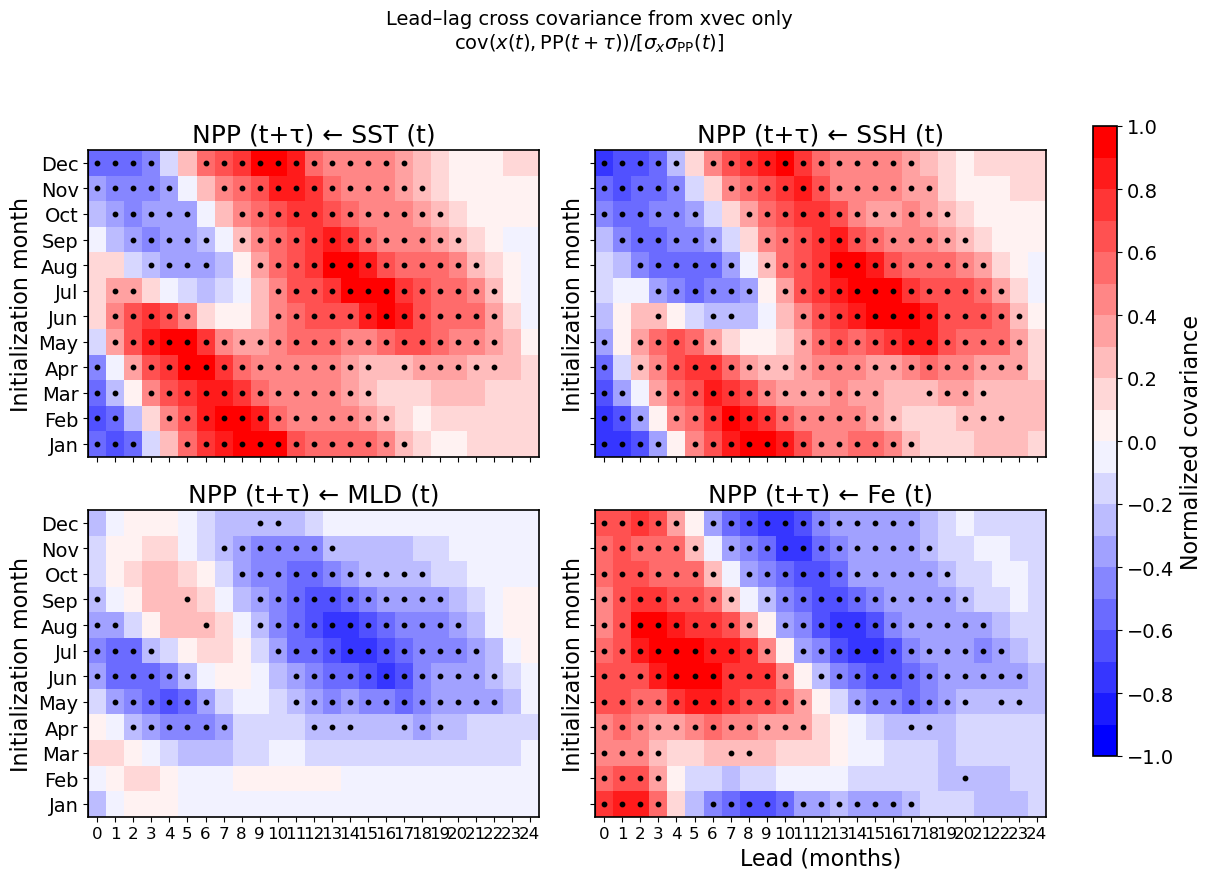

In [17]:
## ensemble mean case

# ==========================================================
# 0. Settings
# ==========================================================
# ens = 0
max_lag = 24
n_month = 12
n_ens = 50   # ensemble members
corr_maps_all = {pname: np.full((n_ens, n_month, max_lag + 1), np.nan)
                 for pname in predictors.values()}

predictors = {
    1: "SST",
    2: "SSH",
    3: "MLD",
    4: "Fe",
}

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# ===== DOF (same as MATLAB) =====
N = 64
nu = N - 2
tcrit = t.ppf(1 - 0.05/2, nu)
rcrit = np.sqrt(tcrit**2 / (tcrit**2 + nu))

# ==========================================================
# 1. Loop over ensemble members
# ==========================================================
for ens in range(n_ens):

    # ------------------------------------------------------
    # 1. Prepare data (this ensemble only)
    # ------------------------------------------------------
    xvec = ds["xvec"].isel(ens_LE=ens).values   # (time, state)
    nt, n_state = xvec.shape

    month_idx = np.tile(np.arange(n_month), nt // n_month)

    # ------------------------------------------------------
    # 2. Month-wise PP(t) std for normalization
    # ------------------------------------------------------
    pp0_std = np.full(n_month, np.nan)

    for m in range(n_month):
        mask = month_idx == m
        pp0 = xvec[mask, 0]
        if np.isfinite(pp0).sum() >= 10:
            pp0_std[m] = np.nanstd(pp0, ddof=1)

    # ------------------------------------------------------
    # 3. Compute lead–lag covariance (this ensemble)
    # ------------------------------------------------------
    for pidx, pname in predictors.items():

        C = np.full((n_month, max_lag + 1), np.nan)

        for m in range(n_month):
            for lag in range(max_lag + 1):

                if lag == 0:
                    tmask = month_idx == m
                    x = xvec[tmask, pidx]
                    y = xvec[tmask, 0]
                else:
                    t0 = np.where(month_idx[:-lag] == m)[0]
                    t1 = t0 + lag
                    x = xvec[t0, pidx]
                    y = xvec[t1, 0]

                valid = np.isfinite(x) & np.isfinite(y)
                if valid.sum() < 10:
                    continue

                xv = x[valid]
                yv = y[valid]

                std_x  = np.nanstd(xv, ddof=1)
                std_pp = pp0_std[m]

                if std_x > 0 and std_pp > 0:
                    cov_xy = np.nanmean(
                        (xv - np.nanmean(xv)) *
                        (yv - np.nanmean(yv))
                    )
                    C[m, lag] = cov_xy / (std_x * std_pp)

        # store this ensemble result
        corr_maps_all[pname][ens, :, :] = C


corr_maps= {
    pname: np.nanmean(C, axis=0)
    for pname, C in corr_maps_all.items()
}

# ==========================================================
# 4. MATLAB-style colormap (blue–white–red, 20)
# ==========================================================
nColors = 20
base_colors = np.array([[0,0,1],
                        [1,1,1],
                        [1,0,0]])
x_base = np.linspace(-1, 1, 3)
x_new  = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))
for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)

# ==========================================================
# 5. Plot heatmaps + significance dots
# ==========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

vmin, vmax = -1, 1

x_edges = np.arange(max_lag + 2)
y_edges = np.arange(n_month + 1)

for i, (pname, C) in enumerate(corr_maps.items()):
    ax = axes[i]

    im = ax.pcolormesh(
        x_edges,
        y_edges,
        C,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        shading="flat"
    )

    # axis orientation: bottom=Jan, top=Dec
    ax.set_xlim(0, max_lag + 1)
    ax.set_ylim(0, n_month)

    # ticks at cell centers
    ax.set_yticks(np.arange(n_month) + 0.5)
    ax.set_yticklabels(month_names)

    ax.set_xticks(np.arange(max_lag + 1) + 0.5)
    ax.set_xticklabels(np.arange(max_lag + 1))

    ax.axvline(0, color="k", lw=0.8)

    ax.set_title(f"NPP (t+τ) ← {pname} (t)")
    ax.set_ylabel("Initialization month")

    # ---- significance dots (same threshold as MATLAB) ----
    sigmask = np.abs(C) >= rcrit
    iy, ix = np.where(sigmask)

    if len(ix) > 0:
        ax.scatter(
            ix + 0.5,
            iy + 0.5,
            s=40,
            c="k",
            marker="."
        )

axes[-1].set_xlabel("Lead (months)")

# ==========================================================
# 6. Colorbar
# ==========================================================
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cb = fig.colorbar(im, cax=cax)
cb.set_label("Normalized covariance")
cb.set_ticks(np.linspace(-1, 1, 11))

fig.suptitle(
    "Lead–lag cross covariance from xvec only\n"
    r"$\mathrm{cov}(x(t), \mathrm{PP}(t+\tau)) / [\sigma_x \sigma_{\mathrm{PP}}(t)]$",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


In [18]:
# ==========================================================
# 0. Settings
# ==========================================================
max_lag = 24
n_month = 12
n_ens   = 50

predictors = {
    1: "PP",
    2: "SST",
    3: "SSH",
    4: "MLD",
    5: "Fe",
}

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# significance (same as MATLAB)
N = 64
nu = N - 2
tcrit = t.ppf(1 - 0.05/2, nu)
rcrit = np.sqrt(tcrit**2 / (tcrit**2 + nu))

# ==========================================================
# 1. Compute C for each ensemble
# ==========================================================
corr_maps_all = {
    pname: np.full((n_ens, n_month, max_lag + 1), np.nan)
    for pname in predictors.values()
}

for ens in range(n_ens):

    xvec = ds["xvec"].isel(ens_LE=ens).values   # (time, state)
    nt, _ = xvec.shape
    month_idx = np.tile(np.arange(n_month), nt // n_month)

    # PP std by month
    pp0_std = np.full(n_month, np.nan)
    for m in range(n_month):
        mask = month_idx == m
        pp0 = xvec[mask, 0]
        if np.isfinite(pp0).sum() >= 10:
            pp0_std[m] = np.nanstd(pp0, ddof=1)

    for pidx, pname in predictors.items():

        C = np.full((n_month, max_lag + 1), np.nan)

        for m in range(n_month):
            for lag in range(max_lag + 1):

                if lag == 0:
                    tmask = month_idx == m
                    x = xvec[tmask, pidx-1]
                    y = xvec[tmask, 0]
                else:
                    t0 = np.where(month_idx[:-lag] == m)[0]
                    t1 = t0 + lag
                    x = xvec[t0, pidx-1]
                    y = xvec[t1, 0]

                valid = np.isfinite(x) & np.isfinite(y)
                if valid.sum() < 10:
                    continue

                xv = x[valid]
                yv = y[valid]

                std_x  = np.nanstd(xv, ddof=1)
                std_pp = pp0_std[m]

                if std_x > 0 and std_pp > 0:
                    cov_xy = np.nanmean(
                        (xv - np.nanmean(xv)) *
                        (yv - np.nanmean(yv))
                    )
                    C[m, lag] = cov_xy / (std_x * std_pp)

        corr_maps_all[pname][ens, :, :] = C

# ensemble mean
corr_maps = {
    pname: np.nanmean(C, axis=0)
    for pname, C in corr_maps_all.items()
}

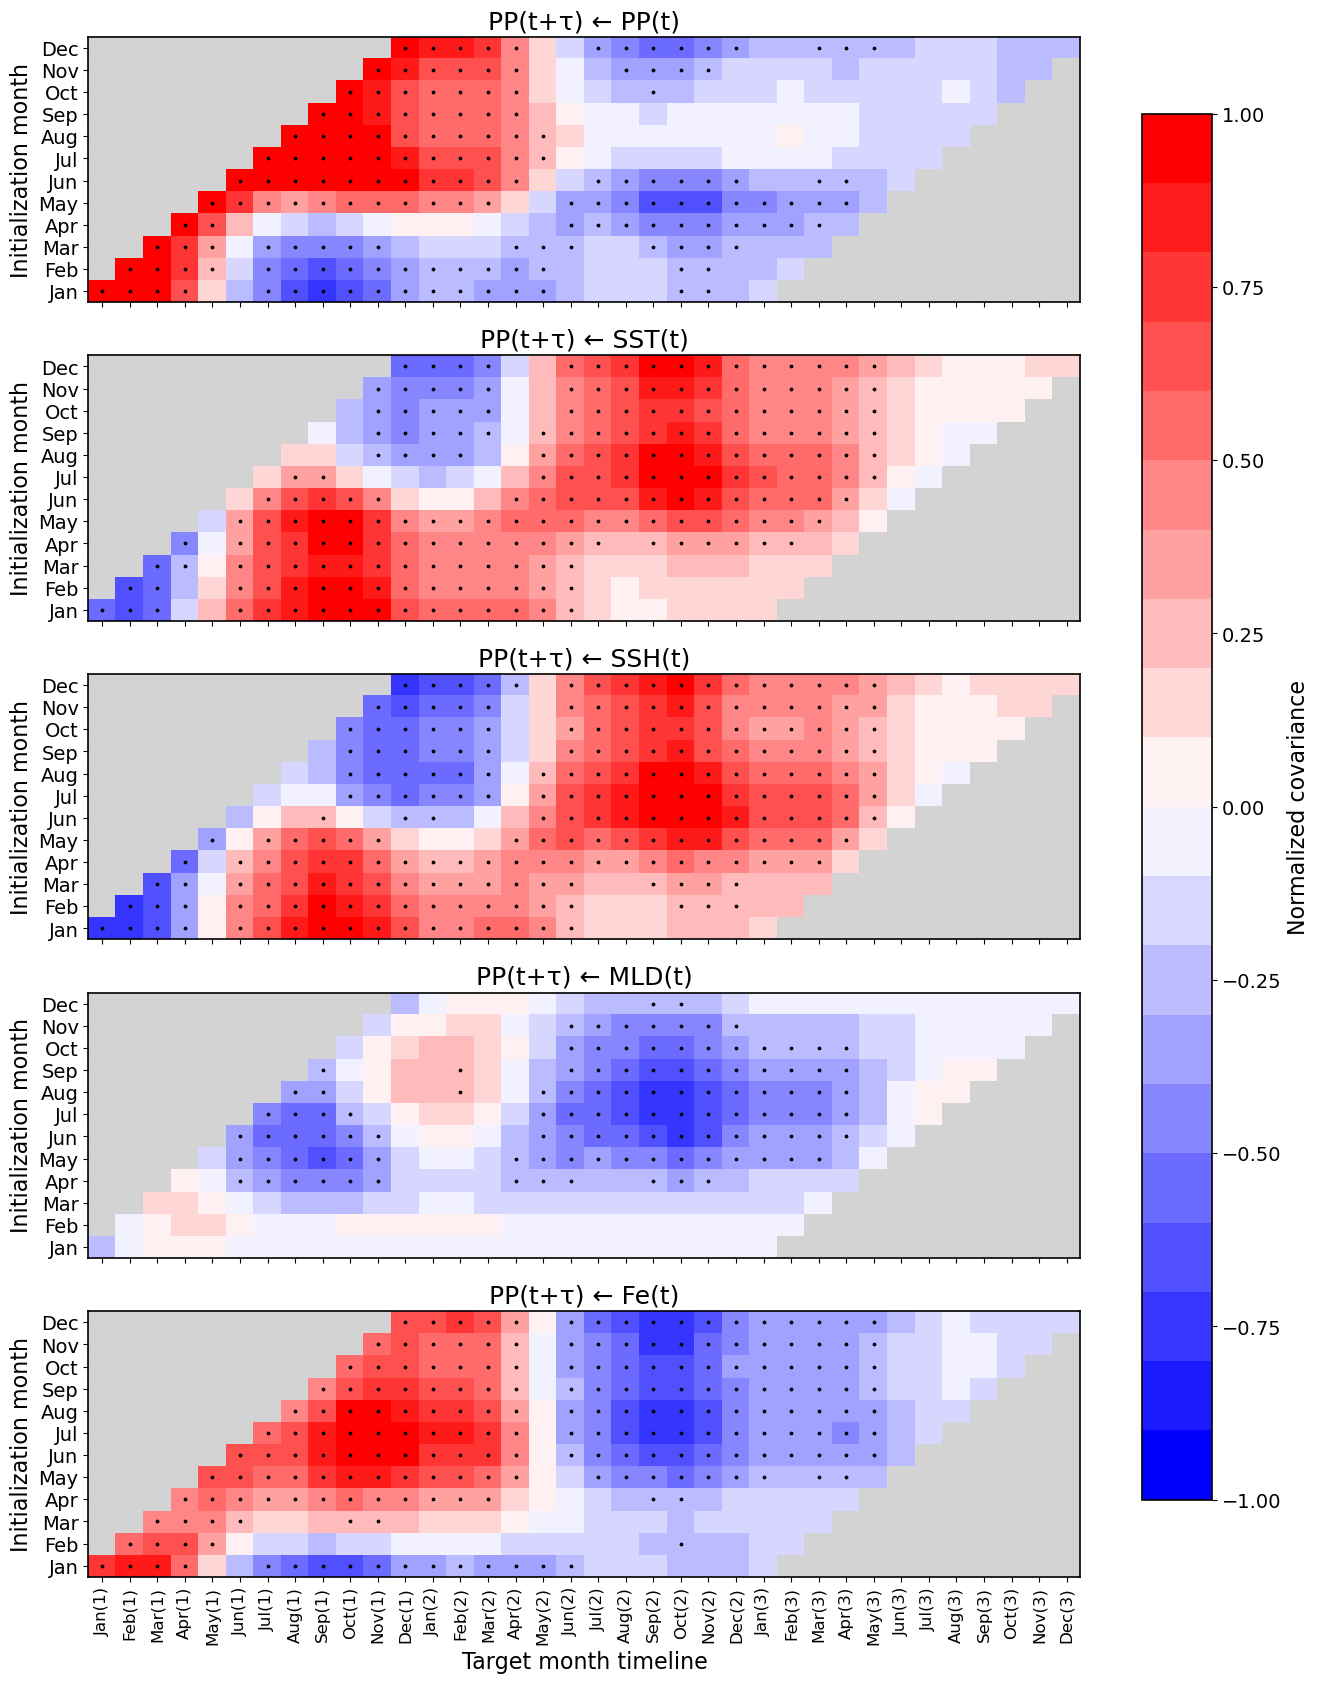

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import t
import matplotlib as mpl


mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 14,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})

# ==========================================================
# 2. ORAS-style target-month alignment
# ==========================================================
def shifted_target_matrix(C, max_lag):
    W = max_lag + 12
    skill = np.full((12, W), np.nan)
    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :]
    return skill

calendar = month_names
labels = []
year = 1
for i in range(max_lag + 12):
    mo = i % 12
    if i > 0 and mo == 0:
        year += 1
    labels.append(f"{calendar[mo]}({year})")

# ==========================================================
# 3. Colormap (MATLAB style)
# ==========================================================
nColors = 20
base_colors = np.array([[0,0,1],[1,1,1],[1,0,0]])
x_base = np.linspace(-1, 1, 3)
x_new  = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))
for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")

# ==========================================================
# 4. Plot (5 × 1)
# ==========================================================
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, (pname, C) in zip(axes, corr_maps.items()):

    skill = shifted_target_matrix(C, max_lag)
    masked = np.ma.masked_invalid(skill)

    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-1,
        vmax=1
    )

    sig = np.abs(skill) >= rcrit
    iy, ix = np.where(sig)
    ax.scatter(ix, iy, s=12, c="k", marker=".")

    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(month_names)
    ax.set_ylabel("Initialization month")
    ax.set_title(f"PP(t+τ) ← {pname}(t)")

axes[-1].set_xticks(np.arange(len(labels)))
axes[-1].set_xticklabels(labels, rotation=90)
axes[-1].set_xlabel("Target month timeline")

cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Normalized covariance")

# plt.tight_layout()
plt.show()


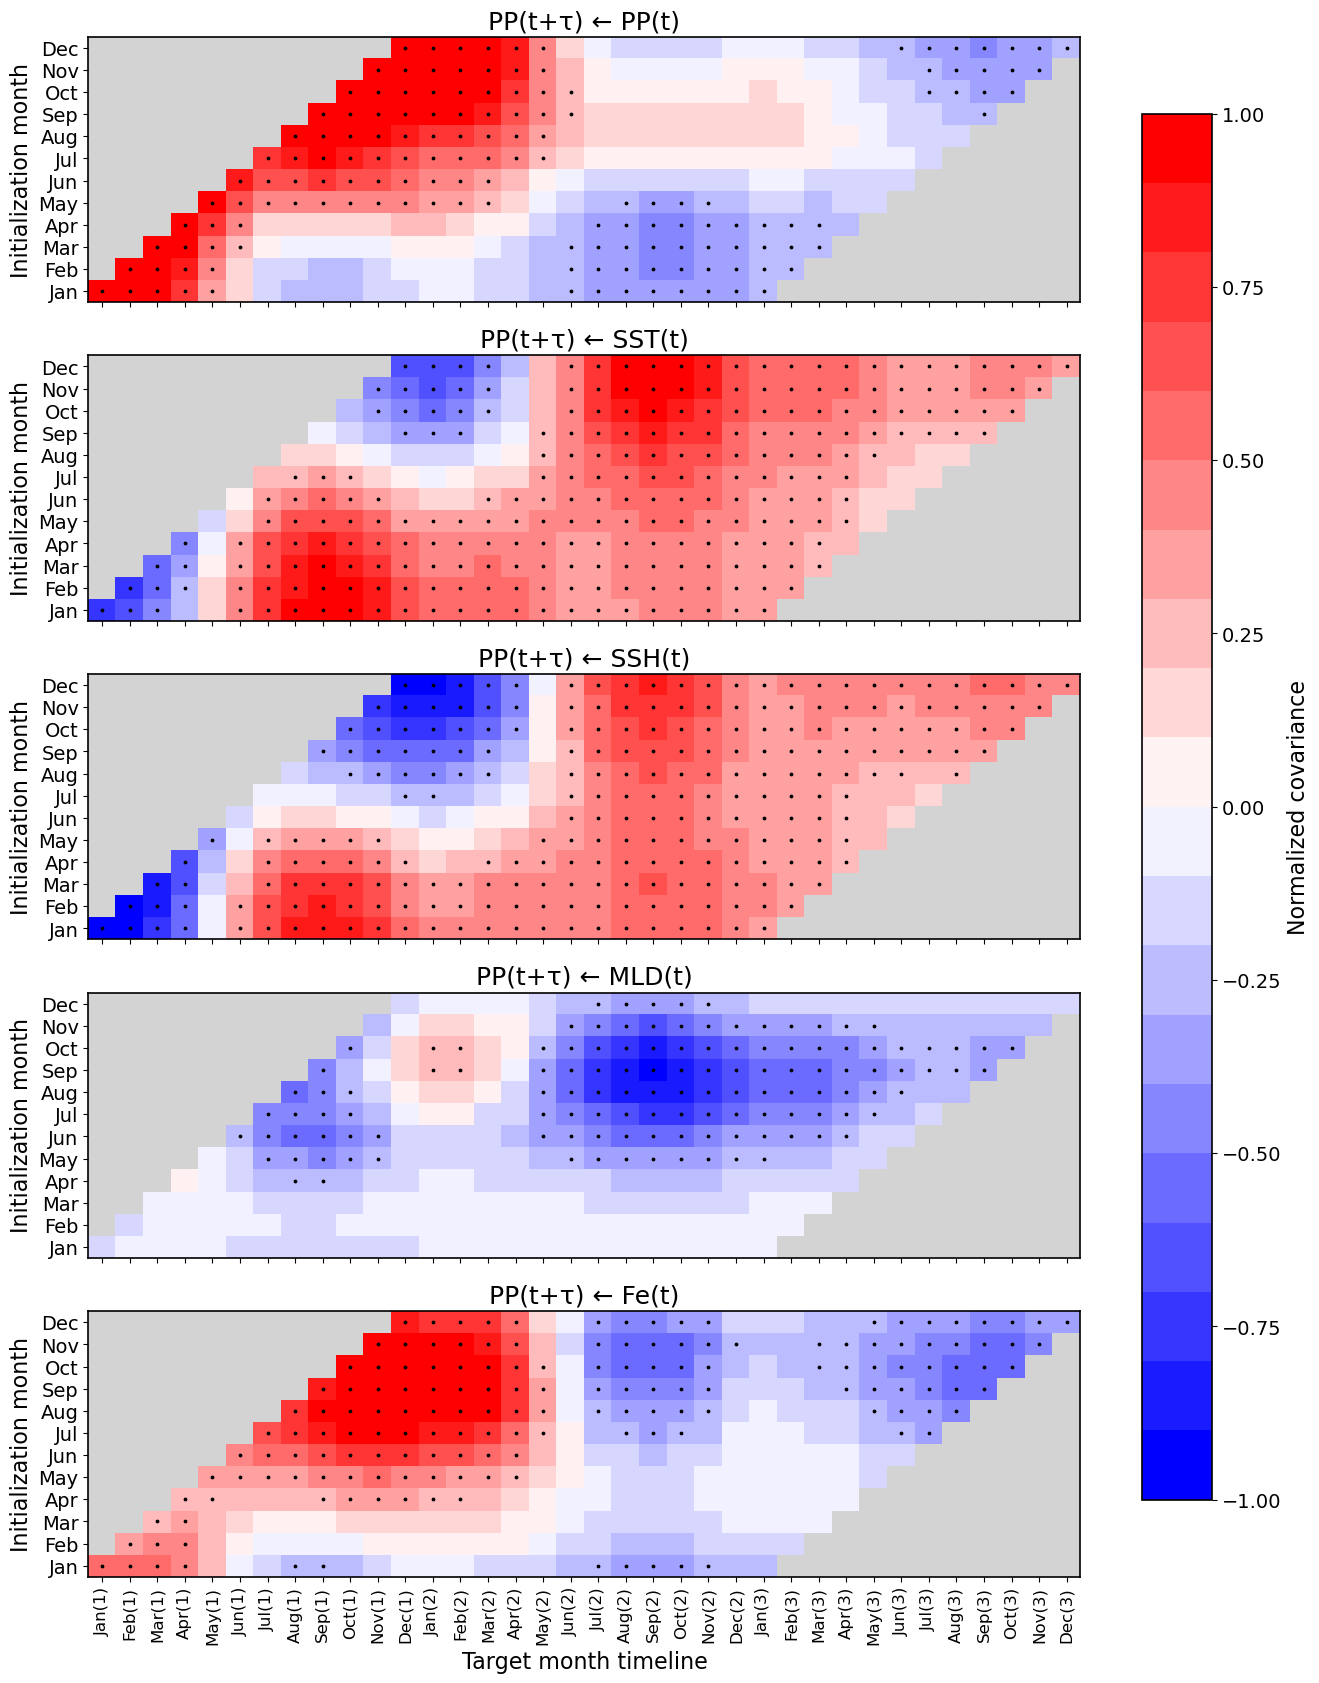

In [25]:



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import t
import matplotlib as mpl


mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 14,
    "figure.titlesize": 20,
    "axes.linewidth": 1.2,
})
corr_maps_LIM = {
    pname: np.full((n_month, max_lag + 1), np.nan)
    for pname in predictors.values()
}
# corr_maps_LIM = {
#     pname: np.full((max_lag + 1, n_month), np.nan)
#     for pname in predictors.values()
# }

for pidx, pname in predictors.items():

    # corr_maps_all[pname][ens, :, :] = ds.K_CS_CW
    corr_maps_LIM[pname] = ds.K_CS_CW.mean(dim='ens_LE').isel(state_i=0).isel(state_j=pidx-1).transpose()
    # corr_maps_LIM[pname] = ds.K_CS_CW.mean(dim='ens_LE').isel(state_i=0).isel(state_j=pidx)

C_PP = (
    ds.K_CS_CW
    .mean(dim="ens_LE")
    .isel(state_i=0, state_j=0)
    .transpose("month", "lead")
    .values
)

corr_maps_LIM_ext = {"PP": C_PP}
corr_maps_LIM_ext.update(corr_maps_LIM)

# ==========================================================
# 2. ORAS-style target-month alignment
# ==========================================================
def shifted_target_matrix(C, max_lag):
    W = max_lag + 12
    skill = np.full((12, W), np.nan)
    for im in range(12):
        skill[im, im:im + max_lag + 1] = C[im, :]
    return skill

calendar = month_names
labels = []
year = 1
for i in range(max_lag + 12):
    mo = i % 12
    if i > 0 and mo == 0:
        year += 1
    labels.append(f"{calendar[mo]}({year})")

# ==========================================================
# 3. Colormap (MATLAB style)
# ==========================================================
nColors = 20
base_colors = np.array([[0,0,1],[1,1,1],[1,0,0]])
x_base = np.linspace(-1, 1, 3)
x_new  = np.linspace(-1, 1, nColors)

cmap_arr = np.zeros((nColors, 3))
for i in range(3):
    cmap_arr[:, i] = np.interp(x_new, x_base, base_colors[:, i])

cmap = ListedColormap(cmap_arr)
cmap.set_bad("lightgray")

# ==========================================================
# 4. Plot (4 × 1)
# ==========================================================
fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for ax, (pname, C) in zip(axes, corr_maps_LIM_ext.items()):

    skill = shifted_target_matrix(C, max_lag)
    masked = np.ma.masked_invalid(skill)

    im = ax.imshow(
        masked,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=-1,
        vmax=1
    )

    sig = np.abs(skill) >= rcrit
    iy, ix = np.where(sig)
    ax.scatter(ix, iy, s=12, c="k", marker=".")

    ax.set_yticks(np.arange(12))
    ax.set_yticklabels(month_names)
    ax.set_ylabel("Initialization month")
    ax.set_title(f"PP(t+τ) ← {pname}(t)")

axes[-1].set_xticks(np.arange(len(labels)))
axes[-1].set_xticklabels(labels, rotation=90)
axes[-1].set_xlabel("Target month timeline")

cbar = fig.colorbar(im, ax=axes, shrink=0.9)
cbar.set_label("Normalized covariance")

# plt.tight_layout()
plt.savefig("/mnt/lustre/proj/kimyy/Figure/LIM/GRL_BGC_LIM/Figure_3.pdf", bbox_inches="tight")
plt.show()


In [21]:
ds.Gam_ST_Colored.isel(ens_LE=3).values

array([0.12, 0.12, 0.12, 0.12, 0.12])

In [22]:
ds.xvec.isel(ens_LE=0).isel(state=0)

<xarray.DataArray 'xvec' (time: 792)> Size: 6kB
dask.array<getitem, shape=(792,), dtype=float64, chunksize=(792,), chunktype=numpy.ndarray>
Coordinates:
    ens_LE   int64 8B 1
Dimensions without coordinates: time

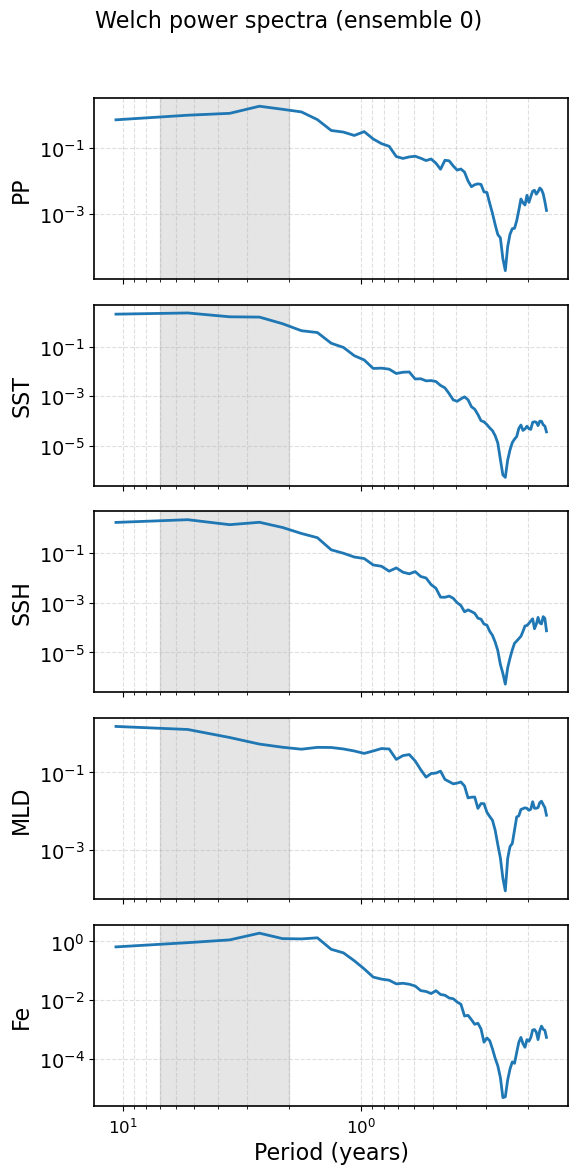

In [23]:
# ==========================================================
# Welch power spectra for all states (PP, SST, SSH, MLD, Fe)
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# ----------------------------------------------------------
# Settings
# ----------------------------------------------------------
fs = 12.0        # monthly sampling (per year)
nperseg = 128

# ----------------------------------------------------------
# Figure (5 × 1)
# ----------------------------------------------------------
fig, axes = plt.subplots(
    nrows=5, ncols=1,
    figsize=(6, 12),
    sharex=True
)

for i, ax in enumerate(axes):

    # ----------------------------------------------
    # Extract state time series
    # ----------------------------------------------
    da = ds.xvec.isel(ens_LE=0, state=i).dropna(dim="time")
    da = da - da.mean(dim="time")   # anomaly

    x = da.values

    # ----------------------------------------------
    # Welch PSD
    # ----------------------------------------------
    freq, psd = welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        detrend=False
    )

    valid = freq > 0
    period = 1.0 / freq[valid]
    psd = psd[valid]

    # ----------------------------------------------
    # Plot
    # ----------------------------------------------
    ax.loglog(period, psd, lw=2)
    ax.invert_xaxis()

    # ENSO band
    ax.axvspan(2, 7, color="gray", alpha=0.2)

    ax.set_ylabel(state_names[i])
    ax.grid(True, which="both", ls="--", alpha=0.4)

# ----------------------------------------------------------
# Shared labels
# ----------------------------------------------------------
axes[-1].set_xlabel("Period (years)")
fig.suptitle("Welch power spectra (ensemble 0)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


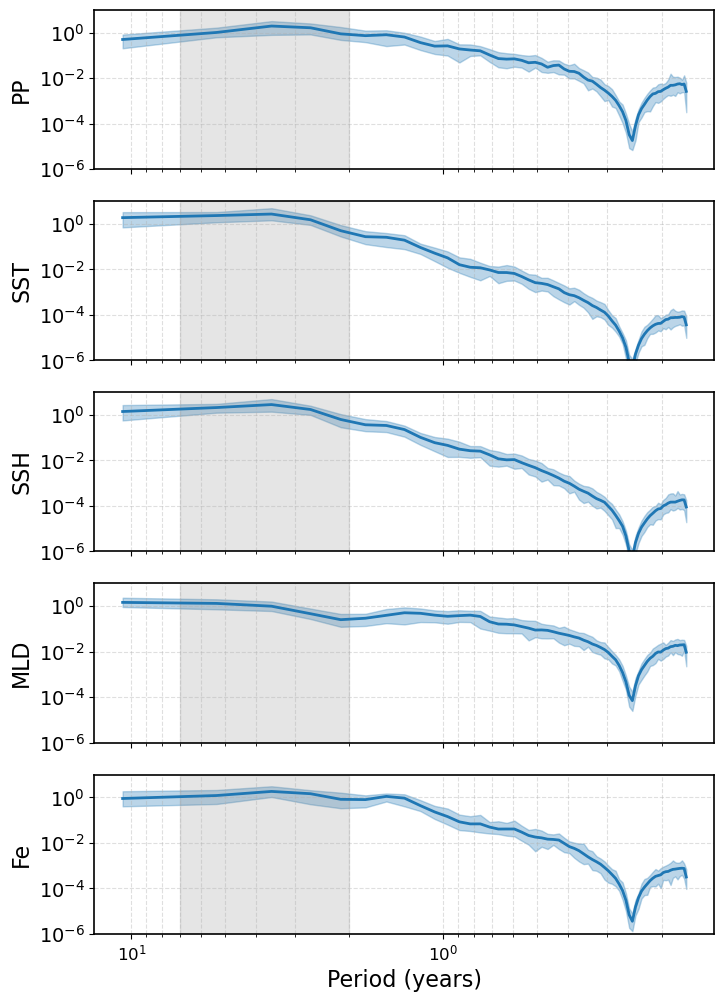

In [24]:
# ==========================================================
# Welch power spectra: ensemble mean + spread
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

state_names = ["PP", "SST", "SSH", "MLD", "Fe"]

# ----------------------------------------------------------
# Settings
# ----------------------------------------------------------
fs = 12.0
nperseg = 128
n_ens = ds.dims["ens_LE"]

# ----------------------------------------------------------
# Figure (5 × 1)
# ----------------------------------------------------------
fig, axes = plt.subplots(
    nrows=5, ncols=1,
    figsize=(8, 12),
    sharex=True
)

for i, ax in enumerate(axes):

    psd_all = []

    # ----------------------------------------------
    # Loop over ensemble members
    # ----------------------------------------------
    for ens in range(n_ens):

        da = ds.xvec.isel(ens_LE=ens, state=i).dropna(dim="time")
        da = da - da.mean(dim="time")
        x = da.values

        freq, psd = welch(
            x,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            detrend=False
        )

        # remove zero frequency
        freq = freq[1:]
        psd = psd[1:]

        # normalize (important for comparison)
        # psd = psd / np.trapz(psd, freq)

        psd_all.append(psd)

    psd_all = np.array(psd_all)

    period = 1.0 / freq

    # ----------------------------------------------
    # Ensemble statistics
    # ----------------------------------------------
    psd_mean = np.nanmean(psd_all, axis=0)
    psd_p25  = np.nanpercentile(psd_all, 0, axis=0)
    psd_p75  = np.nanpercentile(psd_all, 100, axis=0)

    # ----------------------------------------------
    # Plot
    # ----------------------------------------------
    ax.loglog(period, psd_mean, lw=2, color="C0")
    ax.fill_between(
        period, psd_p25, psd_p75,
        color="C0", alpha=0.3
    )

    ax.invert_xaxis()
    ax.axvspan(2, 7, color="gray", alpha=0.2)
    ax.set_ylim(1e-6, 1e1)
    ax.set_ylabel(state_names[i])
    ax.grid(True, which="both", ls="--", alpha=0.4)

# ----------------------------------------------------------
# Shared labels
# ----------------------------------------------------------
axes[-1].set_xlabel("Period (years)")
# fig.suptitle(
#     "Welch power spectra (ensemble mean ± IQR)",
#     fontsize=16
# )
# fig.suptitle(
#     "Welch power spectra ",
#     fontsize=16,
# )

# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
